# SWATCH 데이터 EDA
## 화생방 보호소재 방호성능 분석

### 변수 정의
| 변수 | 설명 | 역할 |
|------|------|------|
| 평량 (g/m²) | 보호소재 단위 면적당 무게 | X (입력) |
| BET (m²/g) | 단위 질량당 미세기공 면적 | X (입력) |
| SWATCH(GD) 24h(Con) | 대류방식 화학작용제(GD) 투과 농도×시간 값 (mg·min/m³) | Y (출력) |
| SWATCH(HD) 24h(Con) | 대류방식 화학작용제(HD) 투과 농도×시간 값 (mg·min/m³) | Y (출력) |

### 미군 방호성능 기준 (24시간 기준, 이하일수록 우수)
- **GD 기준: ≤ 357 mg·min/m³**
- **HD 기준: ≤ 671 mg·min/m³**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 데이터 로드
df = pd.read_excel('datasets/swatch.xlsx')
df.columns = ['Sample', '평량(g/m2)', 'BET(m2/g)', 'GD_Con', 'HD_Con']

# 미군 기준선
GD_LIMIT = 357
HD_LIMIT = 671

print("=== 데이터 기본 정보 ===")
print(f"샘플 수: {len(df)}")
print(f"\n컬럼: {df.columns.tolist()}")
print(f"\n데이터 타입:\n{df.dtypes}")
print(f"\n결측치:\n{df.isnull().sum()}")
print("\n=== 전체 데이터 ===")
display(df)

=== 데이터 기본 정보 ===
샘플 수: 9

컬럼: ['Sample', '평량(g/m2)', 'BET(m2/g)', 'GD_Con', 'HD_Con']

데이터 타입:
Sample        object
평량(g/m2)     float64
BET(m2/g)      int64
GD_Con         int64
HD_Con         int64
dtype: object

결측치:
Sample       0
평량(g/m2)     0
BET(m2/g)    0
GD_Con       0
HD_Con       0
dtype: int64

=== 전체 데이터 ===


,Sample,평량(g/m2),BET(m2/g),GD_Con,HD_Con
0,ACF25-01,105.20,1150,320,280
1,ACF25-02,99.30,1450,470,220
2,ACF25-03,119.70,1150,1150,550
3,ACF25-04,110.40,1300,850,850
4,ACF25-05,103.44,1016,470,580
5,ACF25-06,122.83,1080,20,140
6,ACF25-07,154.49,1139,380,10
7,ACF25-08,140.00,1300,20,5
8,ACF25-09,130.00,2197,50,5


## 1. 기술통계 요약

In [6]:
desc = df.drop(columns='Sample').describe().T
desc['범위'] = desc['max'] - desc['min']
desc['CV(%)'] = (desc['std'] / desc['mean'] * 100).round(1)
print("=== 기술통계 요약 ===")
display(desc.round(2))

print("\n=== Pass/Fail 현황 (미군 기준) ===")
df['GD_pass'] = df['GD_Con'] <= GD_LIMIT
df['HD_pass'] = df['HD_Con'] <= HD_LIMIT
df['ALL_pass'] = df['GD_pass'] & df['HD_pass']

summary = df[['Sample', '평량(g/m2)', 'BET(m2/g)', 'GD_Con', 'HD_Con', 'GD_pass', 'HD_pass', 'ALL_pass']].copy()
summary['GD_pass'] = summary['GD_pass'].map({True: '합격', False: '불합격'})
summary['HD_pass'] = summary['HD_pass'].map({True: '합격', False: '불합격'})
summary['ALL_pass'] = summary['ALL_pass'].map({True: '합격', False: '불합격'})
display(summary)

print(f"\nGD 합격: {df['GD_pass'].sum()}/{len(df)}개")
print(f"HD 합격: {df['HD_pass'].sum()}/{len(df)}개")
print(f"GD+HD 동시 합격: {df['ALL_pass'].sum()}/{len(df)}개")

=== 기술통계 요약 ===


,count,mean,std,min,25%,50%,75%,max,범위,CV(%)
평량(g/m2),9.0,120.60,18.40,99.3,105.2,119.7,130.0,154.49,55.19,15.3
BET(m2/g),9.0,1309.11,358.18,1016.0,1139.0,1150.0,1300.0,2197.00,1181.00,27.4
GD_Con,9.0,414.44,385.85,20.0,50.0,380.0,470.0,1150.00,1130.00,93.1
HD_Con,9.0,293.33,302.81,5.0,10.0,220.0,550.0,850.00,845.00,103.2



=== Pass/Fail 현황 (미군 기준) ===


,Sample,평량(g/m2),BET(m2/g),GD_Con,HD_Con,GD_pass,HD_pass,ALL_pass
0,ACF25-01,105.20,1150,320,280,합격,합격,합격
1,ACF25-02,99.30,1450,470,220,불합격,합격,불합격
2,ACF25-03,119.70,1150,1150,550,불합격,합격,불합격
3,ACF25-04,110.40,1300,850,850,불합격,불합격,불합격
4,ACF25-05,103.44,1016,470,580,불합격,합격,불합격
5,ACF25-06,122.83,1080,20,140,합격,합격,합격
6,ACF25-07,154.49,1139,380,10,불합격,합격,불합격
7,ACF25-08,140.00,1300,20,5,합격,합격,합격
8,ACF25-09,130.00,2197,50,5,합격,합격,합격



GD 합격: 4/9개
HD 합격: 8/9개
GD+HD 동시 합격: 4/9개


## 2. 변수 분포 시각화

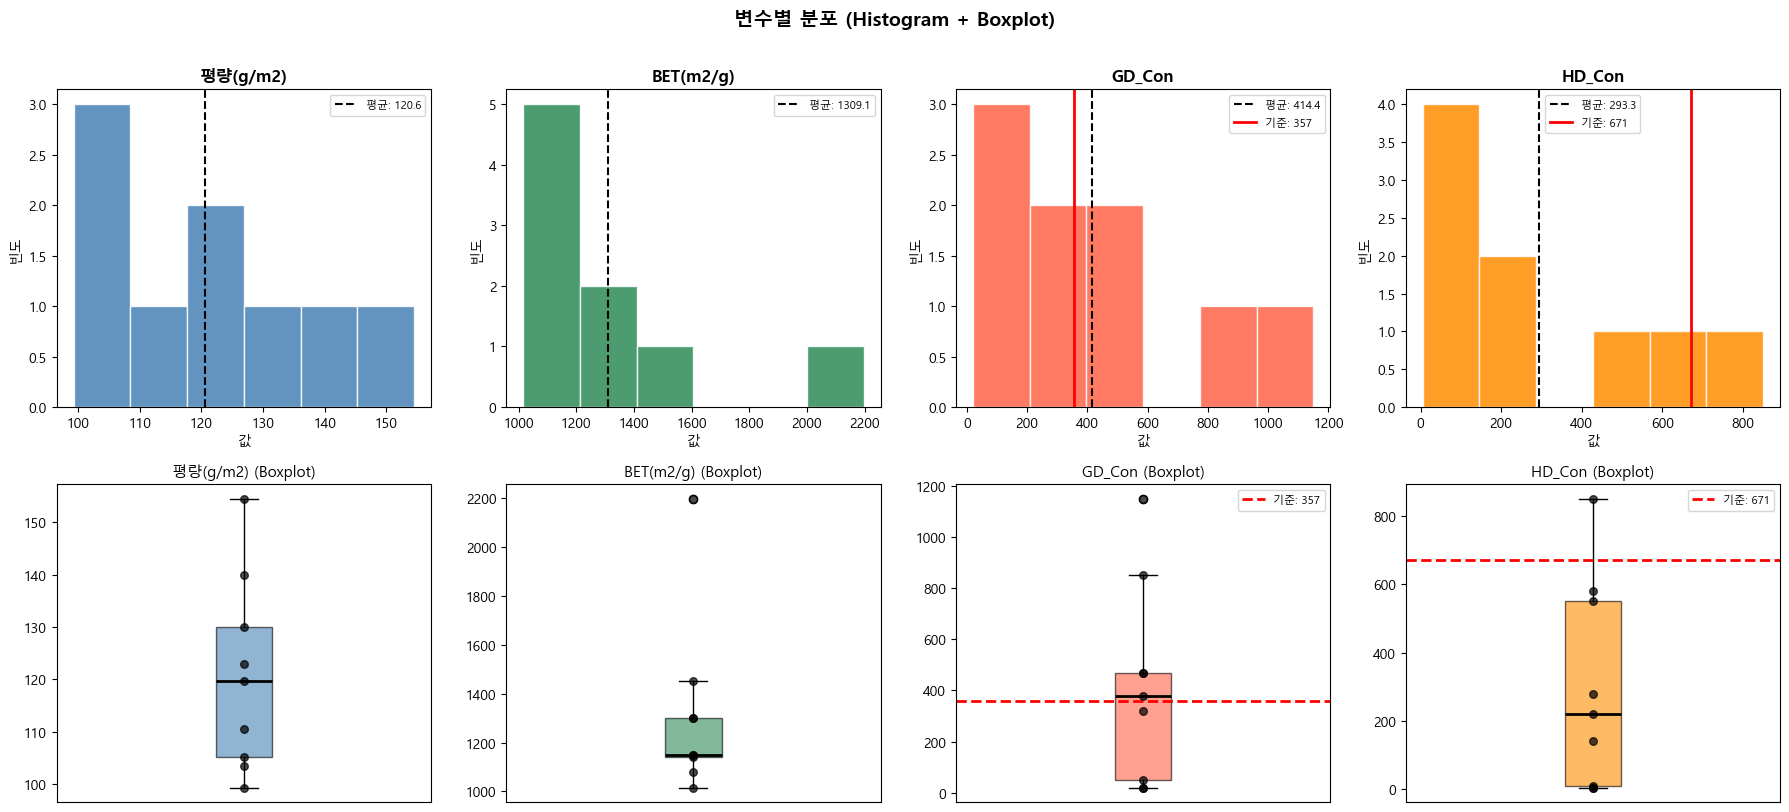

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
cols = ['평량(g/m2)', 'BET(m2/g)', 'GD_Con', 'HD_Con']
limits = [None, None, GD_LIMIT, HD_LIMIT]
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']

for i, (col, lim, color) in enumerate(zip(cols, limits, colors)):
    ax_hist = axes[0, i]
    ax_box  = axes[1, i]

    # Histogram
    ax_hist.hist(df[col], bins=6, color=color, edgecolor='white', alpha=0.85)
    ax_hist.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'평균: {df[col].mean():.1f}')
    if lim:
        ax_hist.axvline(lim, color='red', linestyle='-', linewidth=2, label=f'기준: {lim}')
    ax_hist.set_title(col, fontsize=12, fontweight='bold')
    ax_hist.set_xlabel('값')
    ax_hist.set_ylabel('빈도')
    ax_hist.legend(fontsize=8)

    # Boxplot
    bp = ax_box.boxplot(df[col], patch_artist=True,
                        boxprops=dict(facecolor=color, alpha=0.6),
                        medianprops=dict(color='black', linewidth=2))
    if lim:
        ax_box.axhline(lim, color='red', linestyle='--', linewidth=2, label=f'기준: {lim}')
        ax_box.legend(fontsize=8)
    # 개별 점 표시
    ax_box.scatter([1]*len(df), df[col], color='black', zorder=5, s=30, alpha=0.7)
    ax_box.set_title(f'{col} (Boxplot)', fontsize=11)
    ax_box.set_xticks([])

plt.suptitle('변수별 분포 (Histogram + Boxplot)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. 미군 기준 대비 Pass/Fail 시각화

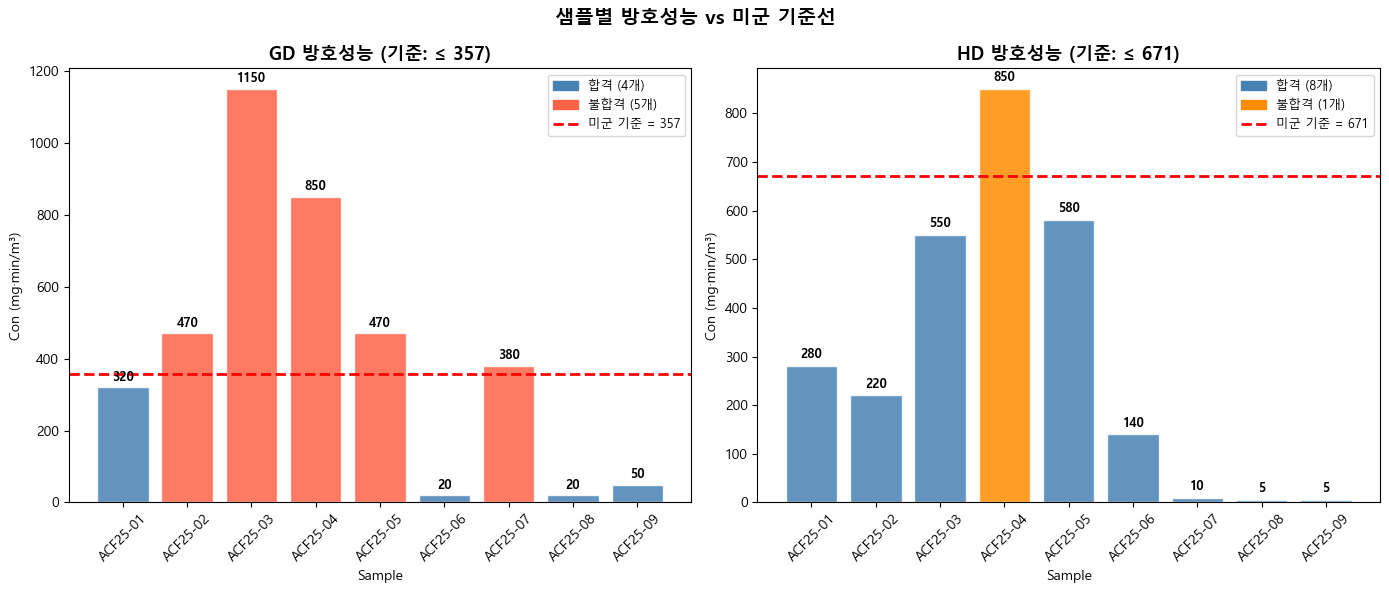

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_col, lim, color, title) in zip(axes, [
    ('GD_Con', GD_LIMIT, 'tomato',    'GD 방호성능 (기준: ≤ 357)'),
    ('HD_Con', HD_LIMIT, 'darkorange','HD 방호성능 (기준: ≤ 671)')
]):
    pass_mask = df[y_col] <= lim
    bar_colors = [color if not p else 'steelblue' for p in pass_mask]

    bars = ax.bar(df['Sample'], df[y_col], color=bar_colors, edgecolor='white', alpha=0.85)
    ax.axhline(lim, color='red', linestyle='--', linewidth=2, label=f'미군 기준 = {lim}')

    # 값 레이블
    for bar, val in zip(bars, df[y_col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Con (mg·min/m³)')
    ax.tick_params(axis='x', rotation=45)

    pass_patch = mpatches.Patch(color='steelblue', label=f'합격 ({pass_mask.sum()}개)')
    fail_patch = mpatches.Patch(color=color, label=f'불합격 ({(~pass_mask).sum()}개)')
    ax.legend(handles=[pass_patch, fail_patch, ax.get_lines()[0]], fontsize=9)

plt.suptitle('샘플별 방호성능 vs 미군 기준선', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 상관관계 분석 (X → Y 산점도)

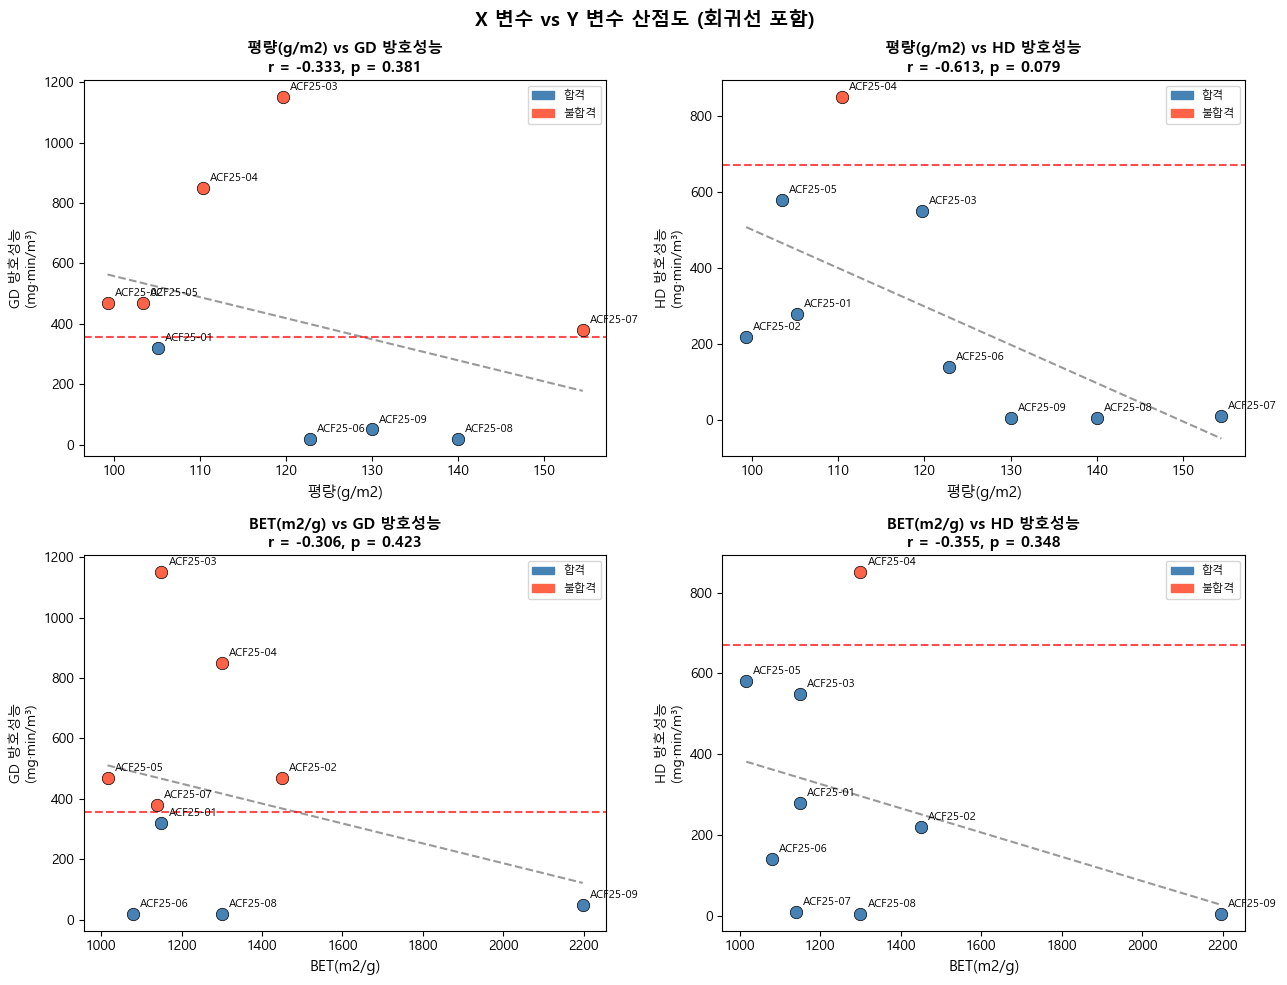

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
pairs = [
    ('평량(g/m2)', 'GD_Con', 'GD 방호성능', 'steelblue', GD_LIMIT),
    ('평량(g/m2)', 'HD_Con', 'HD 방호성능', 'darkorange', HD_LIMIT),
    ('BET(m2/g)',  'GD_Con', 'GD 방호성능', 'seagreen',  GD_LIMIT),
    ('BET(m2/g)',  'HD_Con', 'HD 방호성능', 'mediumpurple', HD_LIMIT),
]

for ax, (x_col, y_col, y_label, color, lim) in zip(axes.flat, pairs):
    x = df[x_col]
    y = df[y_col]

    # 회귀선
    slope, intercept, r, p, se = stats.linregress(x, y)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

    # 산점도 (Pass/Fail 색 구분)
    for _, row in df.iterrows():
        c = 'steelblue' if row[y_col] <= lim else 'tomato'
        ax.scatter(row[x_col], row[y_col], color=c, s=80, zorder=5, edgecolors='black', linewidths=0.5)
        ax.annotate(row['Sample'], (row[x_col], row[y_col]),
                    textcoords='offset points', xytext=(5, 5), fontsize=8)

    # 기준선
    ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'기준={lim}')

    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_label + f'\n(mg·min/m³)', fontsize=10)
    ax.set_title(f'{x_col} vs {y_label}\nr = {r:.3f}, p = {p:.3f}', fontsize=11, fontweight='bold')

    pass_p = mpatches.Patch(color='steelblue', label='합격')
    fail_p = mpatches.Patch(color='tomato', label='불합격')
    ax.legend(handles=[pass_p, fail_p], fontsize=8, loc='upper right')

plt.suptitle('X 변수 vs Y 변수 산점도 (회귀선 포함)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. 상관계수 행렬 (Heatmap)

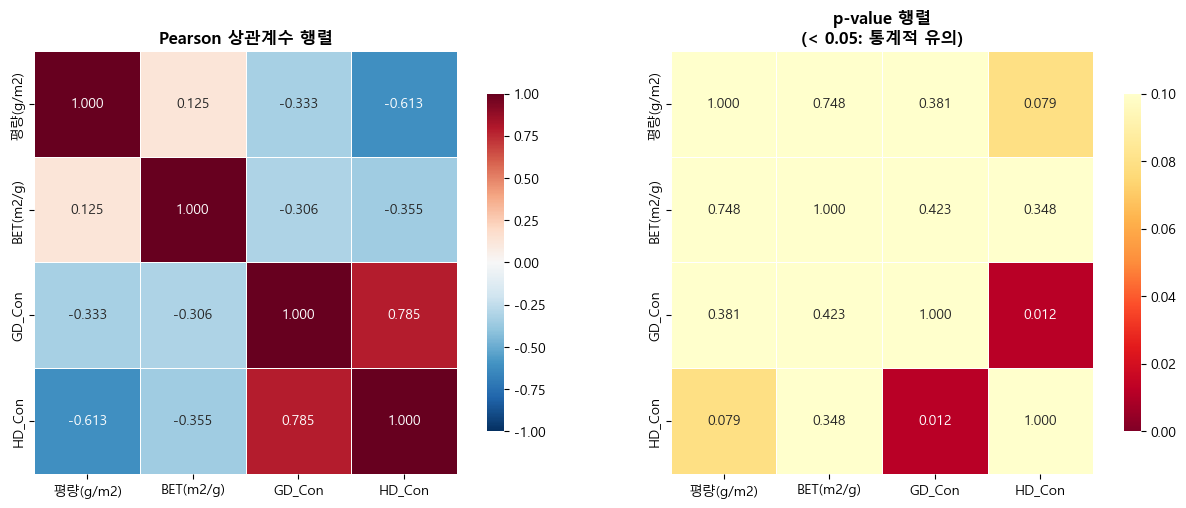


=== 주요 상관계수 요약 (X → Y) ===
  평량(g/m2) vs GD_Con: r = -0.333, p = 0.381  (비유의)
  평량(g/m2) vs HD_Con: r = -0.613, p = 0.079  (비유의)
  BET(m2/g) vs GD_Con: r = -0.306, p = 0.423  (비유의)
  BET(m2/g) vs HD_Con: r = -0.355, p = 0.348  (비유의)


In [10]:
num_cols = ['평량(g/m2)', 'BET(m2/g)', 'GD_Con', 'HD_Con']
corr = df[num_cols].corr()

# p-value 계산
p_mat = pd.DataFrame(np.ones((4,4)), index=num_cols, columns=num_cols)
for i, c1 in enumerate(num_cols):
    for j, c2 in enumerate(num_cols):
        if i != j:
            _, p = stats.pearsonr(df[c1], df[c2])
            p_mat.loc[c1, c2] = p

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pearson 상관계수 heatmap
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson 상관계수 행렬', fontsize=12, fontweight='bold')

# p-value heatmap
sns.heatmap(p_mat.round(3), annot=True, fmt='.3f', cmap='YlOrRd_r',
            vmin=0, vmax=0.1, ax=axes[1],
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title('p-value 행렬\n(< 0.05: 통계적 유의)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== 주요 상관계수 요약 (X → Y) ===")
for x in ['평량(g/m2)', 'BET(m2/g)']:
    for y in ['GD_Con', 'HD_Con']:
        r = corr.loc[x, y]
        p = p_mat.loc[x, y]
        sig = '★ 유의' if p < 0.05 else '(비유의)'
        print(f"  {x} vs {y}: r = {r:.3f}, p = {p:.3f}  {sig}")

## 6. GD vs HD 복합 분석 (2D 합격 구역)

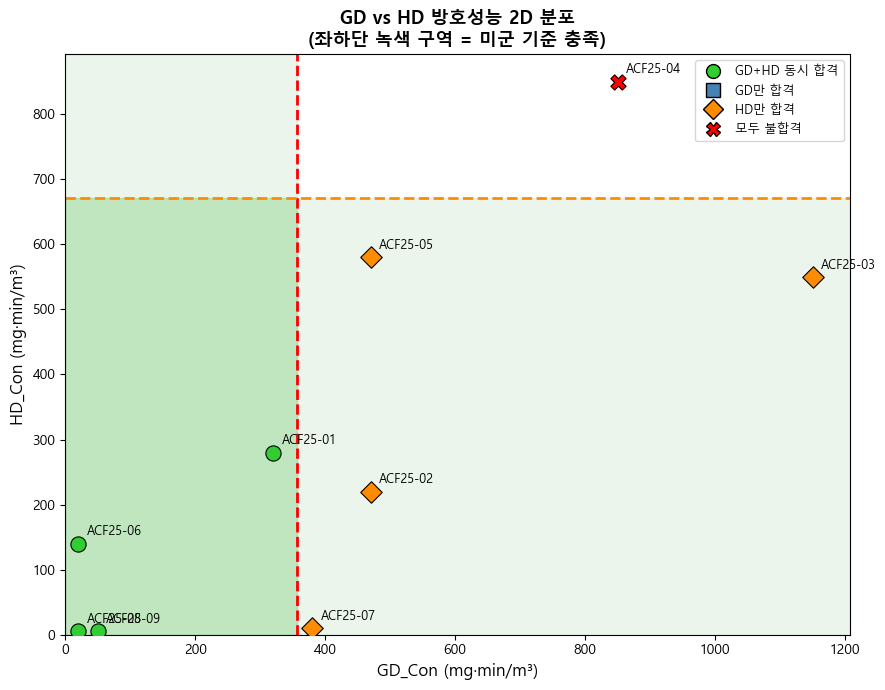

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))

# 합격 구역 음영
ax.axhspan(0, HD_LIMIT, xmin=0, alpha=0.08, color='green')
ax.axvspan(0, GD_LIMIT, alpha=0.08, color='green')
ax.fill_betweenx([0, HD_LIMIT], 0, GD_LIMIT, alpha=0.15, color='limegreen', label='GD+HD 동시 합격 구역')

# 기준선
ax.axvline(GD_LIMIT, color='red', linestyle='--', linewidth=2, label=f'GD 기준 = {GD_LIMIT}')
ax.axhline(HD_LIMIT, color='darkorange', linestyle='--', linewidth=2, label=f'HD 기준 = {HD_LIMIT}')

# 샘플 점
for _, row in df.iterrows():
    both = (row['GD_Con'] <= GD_LIMIT) and (row['HD_Con'] <= HD_LIMIT)
    gd_only = (row['GD_Con'] <= GD_LIMIT) and (row['HD_Con'] > HD_LIMIT)
    hd_only = (row['GD_Con'] > GD_LIMIT) and (row['HD_Con'] <= HD_LIMIT)

    if both:
        c, marker, label = 'limegreen', 'o', 'GD+HD 합격'
    elif gd_only:
        c, marker, label = 'steelblue', 's', 'GD만 합격'
    elif hd_only:
        c, marker, label = 'darkorange', 'D', 'HD만 합격'
    else:
        c, marker, label = 'red', 'X', 'GD+HD 불합격'

    ax.scatter(row['GD_Con'], row['HD_Con'], color=c, marker=marker,
               s=120, zorder=5, edgecolors='black', linewidths=0.8)
    ax.annotate(row['Sample'], (row['GD_Con'], row['HD_Con']),
                textcoords='offset points', xytext=(6, 6), fontsize=9)

# 범례 수동
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen',  markersize=10, label='GD+HD 동시 합격', markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='steelblue',  markersize=10, label='GD만 합격',       markeredgecolor='black'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='darkorange', markersize=10, label='HD만 합격',       markeredgecolor='black'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='red',        markersize=10, label='모두 불합격',     markeredgecolor='black'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

ax.set_xlabel('GD_Con (mg·min/m³)', fontsize=12)
ax.set_ylabel('HD_Con (mg·min/m³)', fontsize=12)
ax.set_title('GD vs HD 방호성능 2D 분포\n(좌하단 녹색 구역 = 미군 기준 충족)', fontsize=13, fontweight='bold')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## 7. Pair Plot (전체 변수 관계)

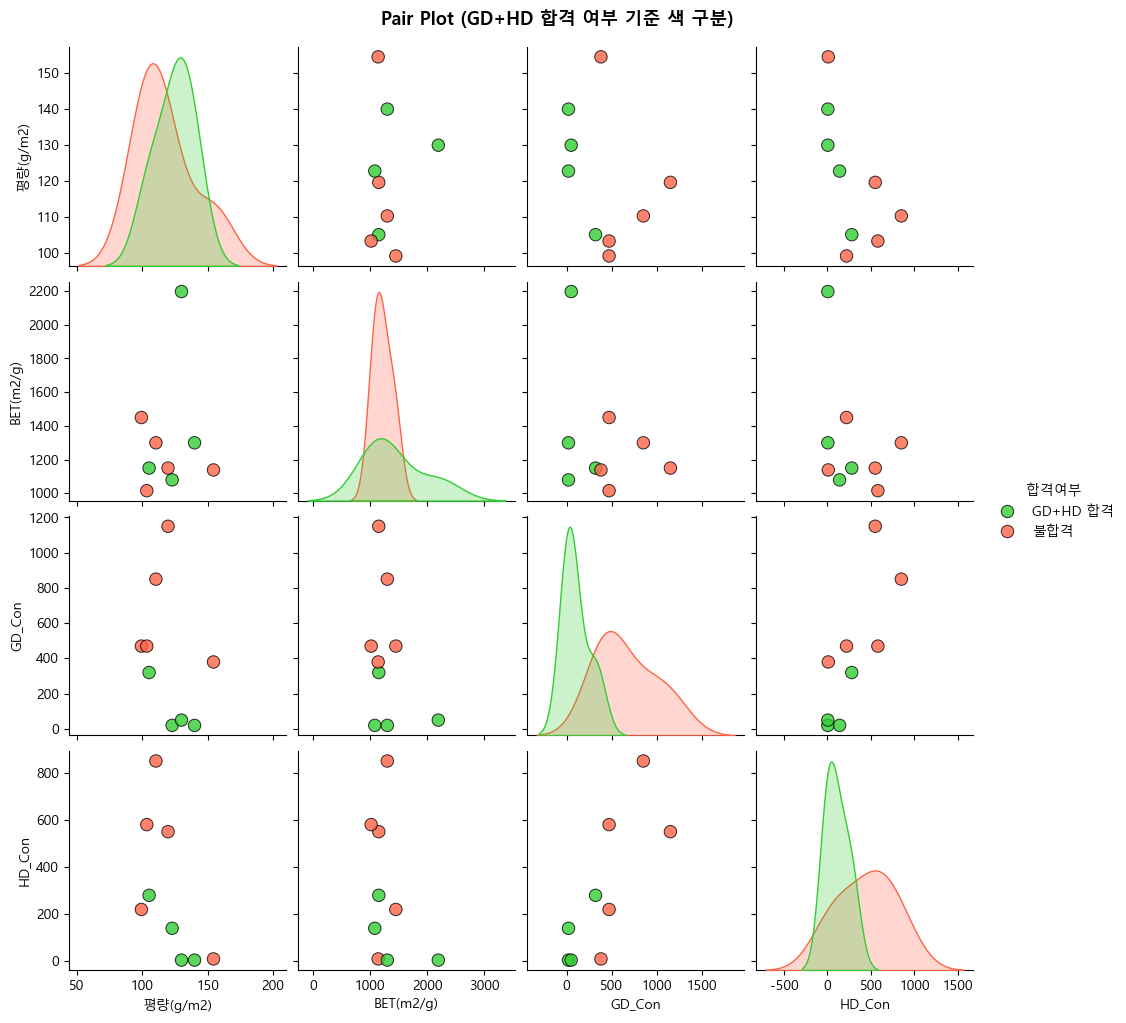

In [12]:
plot_df = df[['평량(g/m2)', 'BET(m2/g)', 'GD_Con', 'HD_Con', 'ALL_pass']].copy()
plot_df['합격여부'] = plot_df['ALL_pass'].map({True: 'GD+HD 합격', False: '불합격'})

g = sns.pairplot(plot_df.drop(columns='ALL_pass'),
                 hue='합격여부',
                 palette={'GD+HD 합격': 'limegreen', '불합격': 'tomato'},
                 diag_kind='kde',
                 plot_kws={'alpha': 0.8, 'edgecolor': 'black', 's': 80},
                 height=2.5)
g.fig.suptitle('Pair Plot (GD+HD 합격 여부 기준 색 구분)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 8. 3D 시각화

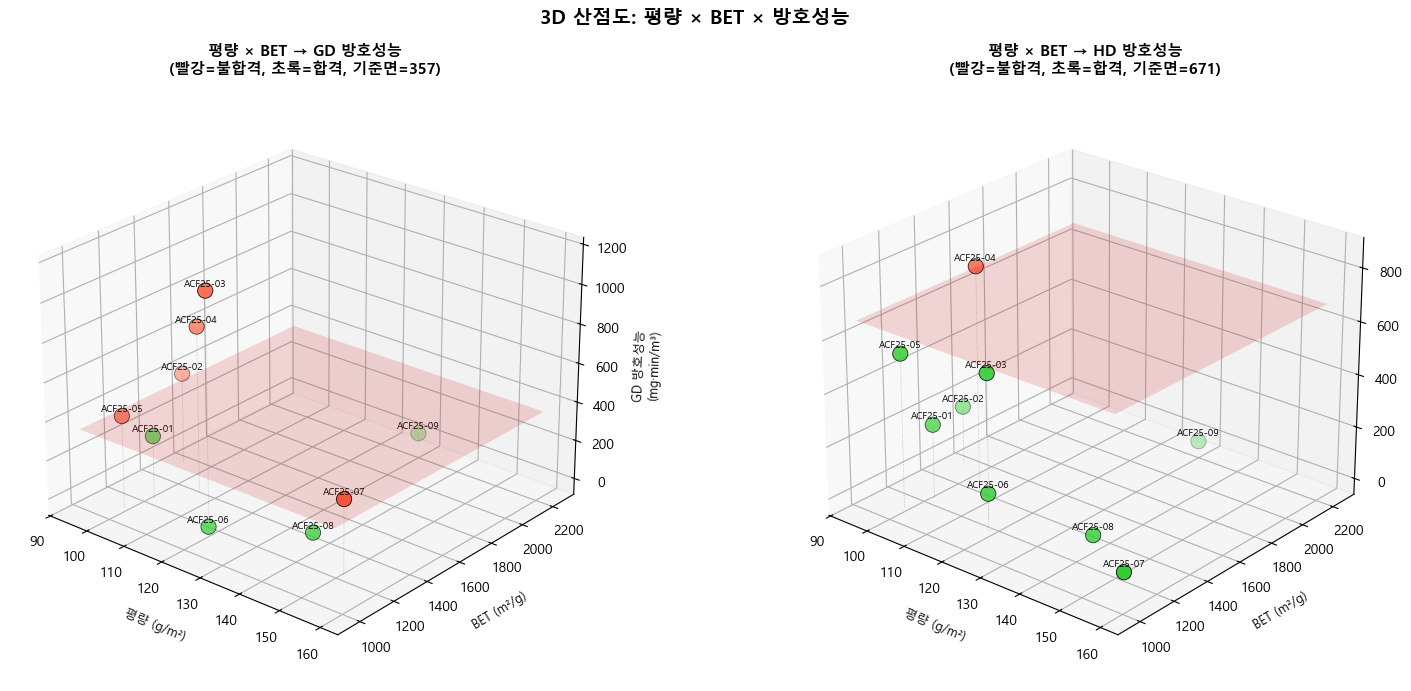

In [13]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 7))

for idx, (y_col, lim, cmap_name, title) in enumerate([
    ('GD_Con', GD_LIMIT, 'RdYlGn_r', 'GD 방호성능'),
    ('HD_Con', HD_LIMIT, 'RdYlGn_r', 'HD 방호성능'),
]):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')

    x = df['평량(g/m2)'].values
    y = df['BET(m2/g)'].values
    z = df[y_col].values

    # Pass/Fail 색 구분
    colors = ['limegreen' if v <= lim else 'tomato' for v in z]
    sizes  = [120] * len(z)

    sc = ax.scatter(x, y, z, c=colors, s=sizes,
                    edgecolors='black', linewidths=0.6, depthshade=True, zorder=5)

    # 기준 평면
    xx, yy = np.meshgrid(
        np.linspace(x.min() - 5,  x.max() + 5,  10),
        np.linspace(y.min() - 50, y.max() + 50, 10)
    )
    zz = np.full_like(xx, lim)
    ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

    # 바닥에 수직 투영선
    for xi, yi, zi in zip(x, y, z):
        ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

    # 샘플 레이블
    for _, row in df.iterrows():
        ax.text(row['평량(g/m2)'], row['BET(m2/g)'], row[y_col] + 20,
                row['Sample'], fontsize=7, ha='center')

    ax.set_xlabel('평량 (g/m²)', fontsize=9, labelpad=8)
    ax.set_ylabel('BET (m²/g)',  fontsize=9, labelpad=8)
    ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)
    ax.set_title(f'평량 × BET → {title}\n(빨강=불합격, 초록=합격, 기준면={lim})',
                 fontsize=11, fontweight='bold', pad=12)
    ax.view_init(elev=25, azim=-50)

plt.suptitle('3D 산점도: 평량 × BET × 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

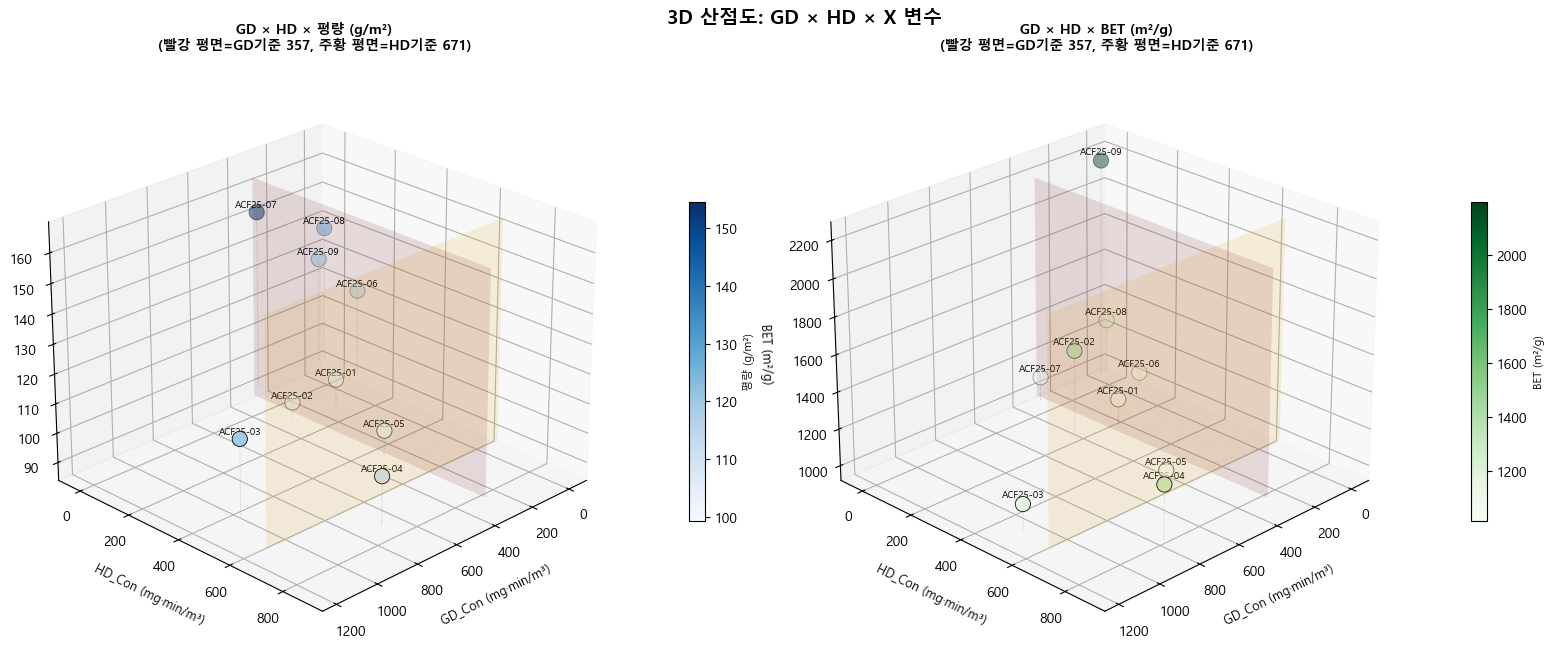

In [14]:
# GD vs HD vs 평량 / GD vs HD vs BET
fig = plt.figure(figsize=(16, 7))

for idx, (z_col, z_label, cmap) in enumerate([
    ('평량(g/m2)', '평량 (g/m²)', 'Blues'),
    ('BET(m2/g)',  'BET (m²/g)',  'Greens'),
]):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')

    x = df['GD_Con'].values
    y = df['HD_Con'].values
    z = df[z_col].values

    sc = ax.scatter(x, y, z, c=z, cmap=cmap, s=120,
                    edgecolors='black', linewidths=0.6, depthshade=True)

    # GD 기준 평면 (x = GD_LIMIT)
    yy2, zz2 = np.meshgrid(
        np.linspace(y.min() - 30, y.max() + 30, 10),
        np.linspace(z.min() - 10, z.max() + 10, 10)
    )
    xx2 = np.full_like(yy2, GD_LIMIT)
    ax.plot_surface(xx2, yy2, zz2, alpha=0.12, color='red')

    # HD 기준 평면 (y = HD_LIMIT)
    xx3, zz3 = np.meshgrid(
        np.linspace(x.min() - 30, x.max() + 30, 10),
        np.linspace(z.min() - 10, z.max() + 10, 10)
    )
    yy3 = np.full_like(xx3, HD_LIMIT)
    ax.plot_surface(xx3, yy3, zz3, alpha=0.12, color='orange')

    # 수직 투영선
    for xi, yi, zi in zip(x, y, z):
        ax.plot([xi, xi], [yi, yi], [z.min() - 5, zi],
                color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

    # 샘플 레이블
    for _, row in df.iterrows():
        ax.text(row['GD_Con'], row['HD_Con'], row[z_col] + (z.max()-z.min())*0.03,
                row['Sample'], fontsize=7, ha='center')

    cbar = fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.1)
    cbar.set_label(z_label, fontsize=8)

    ax.set_xlabel('GD_Con (mg·min/m³)', fontsize=9, labelpad=8)
    ax.set_ylabel('HD_Con (mg·min/m³)', fontsize=9, labelpad=8)
    ax.set_zlabel(z_label, fontsize=9, labelpad=8)
    ax.set_title(f'GD × HD × {z_label}\n(빨강 평면=GD기준 {GD_LIMIT}, 주황 평면=HD기준 {HD_LIMIT})',
                 fontsize=10, fontweight='bold', pad=12)
    ax.view_init(elev=25, azim=45)

plt.suptitle('3D 산점도: GD × HD × X 변수', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 다중 회귀분석 (평량 + BET → 방호성능)

### 분석 개요

**다중 선형 회귀(Multiple Linear Regression)** 는 2개 이상의 독립변수(X)로 하나의 종속변수(Y)를 선형 방정식으로 예측하는 기법입니다.

$$Y = \beta_0 + \beta_1 \cdot \text{평량} + \beta_2 \cdot \text{BET} + \varepsilon$$

| 기호 | 의미 |
|------|------|
| β₀ | 절편 — 모든 X가 0일 때의 Y 예측값 (물리적 해석보다 수식 보정 역할) |
| β₁ | 평량 계수 — 평량 1 g/m² 증가 시 Y 변화량 |
| β₂ | BET 계수 — BET 1 m²/g 증가 시 Y 변화량 |
| ε  | 잔차(오차) — 모델이 설명하지 못한 나머지 변동 |

**계수 해석 핵심**: 부호(방향), 크기(영향력), p-value(통계적 유의성)를 함께 확인합니다.

---

### 주요 적합도 지표

| 지표 | 범위 | 해석 |
|------|------|------|
| **R²** | 0 ~ 1 | 모델이 Y 분산을 설명하는 비율. 1에 가까울수록 설명력 우수 |
| **Adj. R²** | ≤ R² | 변수 수를 보정한 R². 진짜 기여 없는 변수 추가 시 오히려 감소 → 더 엄격한 지표 |
| **RMSE** | ≥ 0 | 예측 오차의 평균 크기 (단위: mg·min/m³). 작을수록 예측 정확 |
| **F-stat p-value** | 0 ~ 1 | 전체 모델 유의성. < 0.05이면 "X들이 Y를 유의하게 설명" |
| **계수 p-value** | 0 ~ 1 | 각 변수의 개별 유의성. < 0.05이면 해당 변수가 유의한 기여 |

> ⚠️ **n=9 소규모 주의**: p-value가 0.05를 넘어도 실질적 경향이 있을 수 있고, 반대로 우연히 유의하게 나올 수도 있습니다. 계수의 방향과 도메인 지식을 반드시 함께 고려하세요.

In [15]:
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

X_raw = df[['평량(g/m2)', 'BET(m2/g)']].values
X_sm  = sm.add_constant(X_raw)   # statsmodels용 (상수항 추가)

results = {}
for y_col, label in [('GD_Con', 'GD'), ('HD_Con', 'HD')]:
    y = df[y_col].values
    model = sm.OLS(y, X_sm).fit()

    y_pred = model.fittedvalues
    n, p = len(y), 2
    adj_r2 = 1 - (1 - model.rsquared) * (n - 1) / (n - p - 1)
    rmse   = np.sqrt(mean_squared_error(y, y_pred))

    results[y_col] = {
        'model': model, 'y_pred': y_pred,
        'r2': model.rsquared, 'adj_r2': adj_r2, 'rmse': rmse
    }

    print(f"\n{'='*54}")
    print(f"  다중 회귀 결과: X=[평량, BET]  →  Y={label}_Con")
    print(f"{'='*54}")
    print(f"  계수:")
    print(f"    절편(β₀)   = {model.params[0]:+.4f}")
    print(f"    평량(β₁)   = {model.params[1]:+.4f}  (p={model.pvalues[1]:.4f})")
    print(f"    BET(β₂)    = {model.params[2]:+.4f}  (p={model.pvalues[2]:.4f})")
    print(f"  적합도:")
    print(f"    R²         = {model.rsquared:.4f}")
    print(f"    Adj. R²    = {adj_r2:.4f}")
    print(f"    RMSE       = {rmse:.2f}")
    print(f"    F-stat     = {model.fvalue:.4f}  (p={model.f_pvalue:.4f})")
    print(f"\n  회귀식: {label} = {model.params[0]:.2f}"
          f" {model.params[1]:+.4f}·평량"
          f" {model.params[2]:+.4f}·BET")


  다중 회귀 결과: X=[평량, BET]  →  Y=GD_Con
  계수:
    절편(β₀)   = +1549.9122
    평량(β₁)   = -6.2773  (p=0.4520)
    BET(β₂)    = -0.2891  (p=0.4980)
  적합도:
    R²         = 0.1818
    Adj. R²    = -0.0910
    RMSE       = 329.06
    F-stat     = 0.6664  (p=0.5478)

  회귀식: GD = 1549.91 -6.2773·평량 -0.2891·BET

  다중 회귀 결과: X=[평량, BET]  →  Y=HD_Con
  계수:
    절편(β₀)   = +1751.9803
    평량(β₁)   = -9.4996  (p=0.1064)
    BET(β₂)    = -0.2391  (p=0.3881)
  적합도:
    R²         = 0.4541
    Adj. R²    = 0.2722
    RMSE       = 210.93
    F-stat     = 2.4957  (p=0.1627)

  회귀식: HD = 1751.98 -9.4996·평량 -0.2391·BET


In [ ]:
# ── 결과 자동 해석 출력 ──
for y_col, label, lim in [('GD_Con','GD',GD_LIMIT), ('HD_Con','HD',HD_LIMIT)]:
    m      = results[y_col]['model']
    b0, b1, b2 = m.params
    p1, p2 = m.pvalues[1], m.pvalues[2]
    r2     = results[y_col]['r2']
    adj_r2 = results[y_col]['adj_r2']
    rmse   = results[y_col]['rmse']
    f_p    = m.f_pvalue

    print(f"\n{'━'*54}")
    print(f"  [{label}] 회귀 결과 해석")
    print(f"{'━'*54}")

    # 모델 전체 유의성
    if f_p < 0.05:
        print(f"  ✅ 전체 모델 유의 (F p={f_p:.4f} < 0.05)")
        print(f"     → 평량·BET 조합이 {label} 방호성능을 유의하게 설명합니다.")
    else:
        print(f"  ⚠️  전체 모델 비유의 (F p={f_p:.4f} ≥ 0.05)")
        print(f"     → n=9 소규모로 통계 검정력 부족. 경향 자체는 참고 가능합니다.")

    # 설명력
    print(f"\n  📊 설명력: R²={r2:.3f} → {label} 분산의 {r2*100:.1f}%를 모델이 설명")
    if adj_r2 < r2 - 0.05:
        print(f"     Adj.R²={adj_r2:.3f} (R²와 차이 큼 → 변수 중 하나가 기여 미미할 수 있음)")
    else:
        print(f"     Adj.R²={adj_r2:.3f} (R²와 유사 → 두 변수 모두 기여)")
    print(f"     RMSE={rmse:.1f} mg·min/m³ (평균 예측 오차)")

    # 개별 계수 해석
    print(f"\n  📌 계수 해석:")
    dir1 = "증가" if b1 > 0 else "감소"
    dir2 = "증가" if b2 > 0 else "감소"
    sig1 = "★ 유의" if p1 < 0.05 else "(비유의, 참고)"
    sig2 = "★ 유의" if p2 < 0.05 else "(비유의, 참고)"
    print(f"    평량 β₁={b1:+.3f} → 평량 1 g/m² 증가 시 {label} {abs(b1):.3f} {dir1}  {sig1}")
    print(f"    BET  β₂={b2:+.4f} → BET 1 m²/g 증가 시 {label} {abs(b2):.4f} {dir2}  {sig2}")

    # 도메인 해석
    print(f"\n  🔍 도메인 관점:")
    if b2 < 0:
        print(f"     BET↑ → {label}↓: 미세기공이 많을수록 화학작용제 흡착 면적이 늘어 방호성능 향상 (예상 부합)")
    else:
        print(f"     BET↑ → {label}↑: 예상과 반대 방향 — 다른 구조적 요인이 개입했을 가능성 검토 필요")
    if b1 > 0:
        print(f"     평량↑ → {label}↑: 무거울수록 투과량 증가 — 단순 무게보다 구조·기공 특성이 더 중요할 수 있음")
    else:
        print(f"     평량↑ → {label}↓: 무거울수록 방호성능 향상 — 두꺼울수록 장벽 효과가 커지는 것으로 해석 가능")

### 9-1. 평량 × BET → GD (3D 회귀 평면)

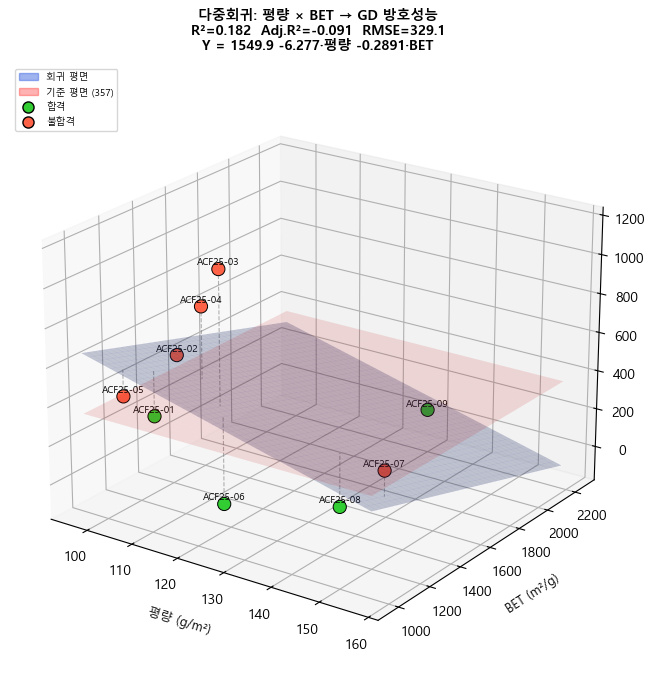

In [16]:
def plot_regression_3d(ax, df, y_col, lim, title, elev=25, azim=-50):
    m   = results[y_col]['model']
    b0, b1, b2 = m.params

    x1 = df['평량(g/m2)'].values
    x2 = df['BET(m2/g)'].values
    y  = df[y_col].values
    y_pred = results[y_col]['y_pred']
    r2     = results[y_col]['r2']
    adj_r2 = results[y_col]['adj_r2']
    rmse   = results[y_col]['rmse']

    # 회귀 평면 생성
    x1_grid = np.linspace(x1.min() - 3,  x1.max() + 3,  40)
    x2_grid = np.linspace(x2.min() - 50, x2.max() + 50, 40)
    X1g, X2g = np.meshgrid(x1_grid, x2_grid)
    Zg = b0 + b1 * X1g + b2 * X2g

    # 회귀 평면 (파란색)
    ax.plot_surface(X1g, X2g, Zg, alpha=0.25, color='royalblue', edgecolor='none')
    ax.plot_wireframe(X1g, X2g, Zg, alpha=0.08, color='navy', linewidth=0.3)

    # 미군 기준 평면 (빨간색)
    Zlim = np.full_like(X1g, lim)
    ax.plot_surface(X1g, X2g, Zlim, alpha=0.12, color='red', edgecolor='none')

    # 실제 점 → 예측값 잔차선
    for xi1, xi2, yi, yp in zip(x1, x2, y, y_pred):
        ax.plot([xi1, xi1], [xi2, xi2], [yi, yp],
                color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

    # 산점도 (Pass/Fail 색)
    colors = ['limegreen' if v <= lim else 'tomato' for v in y]
    ax.scatter(x1, x2, y, c=colors, s=90,
               edgecolors='black', linewidths=0.7, depthshade=False, zorder=10)

    # 샘플 레이블
    for _, row in df.iterrows():
        ax.text(row['평량(g/m2)'], row['BET(m2/g)'], row[y_col] + 18,
                row['Sample'], fontsize=7, ha='center', color='black')

    ax.set_xlabel('평량 (g/m²)', fontsize=9, labelpad=8)
    ax.set_ylabel('BET (m²/g)',  fontsize=9, labelpad=8)
    ax.set_zlabel(f'{y_col} (mg·min/m³)', fontsize=9, labelpad=8)
    ax.set_title(
        f'{title}\n'
        f'R²={r2:.3f}  Adj.R²={adj_r2:.3f}  RMSE={rmse:.1f}\n'
        f'Y = {b0:.1f} {b1:+.3f}·평량 {b2:+.4f}·BET',
        fontsize=10, fontweight='bold', pad=10
    )
    ax.view_init(elev=elev, azim=azim)

    # 범례 패치
    from matplotlib.lines import Line2D
    leg = [
        mpatches.Patch(color='royalblue', alpha=0.5, label='회귀 평면'),
        mpatches.Patch(color='red',       alpha=0.3, label=f'기준 평면 ({lim})'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='limegreen',
               markersize=8, label='합격', markeredgecolor='black'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
               markersize=8, label='불합격', markeredgecolor='black'),
    ]
    ax.legend(handles=leg, fontsize=7, loc='upper left')

# ── Case 1: GD ──
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
plot_regression_3d(ax, df, 'GD_Con', GD_LIMIT,
                   '다중회귀: 평량 × BET → GD 방호성능', elev=22, azim=-55)
plt.tight_layout()
plt.show()

#### 📌 9-1 시각화 독해 가이드 (GD)

| 요소 | 의미 |
|------|------|
| **파란 회귀 평면** | 모델이 예측하는 GD값의 경향면. 평량·BET가 변할 때 GD가 어떻게 달라지는지 보여줌 |
| **빨간 수평 기준면** | GD = 357 (미군 기준). 이 면 **아래**에 위치한 점이 합격 |
| **초록 점** | 실제 GD ≤ 357 → 합격 샘플 |
| **빨간 점** | 실제 GD > 357 → 불합격 샘플 |
| **점선 (잔차선)** | 실제값 ↔ 회귀 평면 위 예측값 간 거리 = **잔차**. 짧을수록 예측이 정확 |

**읽는 법**: 회귀 평면의 **기울기 방향**을 보세요.
- 평량 축 방향으로 평면이 올라가면 β₁ > 0 (평량 증가 → GD 증가)
- BET 축 방향으로 평면이 내려가면 β₂ < 0 (BET 증가 → GD 감소, 즉 방호성능 향상)

### 9-2. 평량 × BET → HD (3D 회귀 평면)

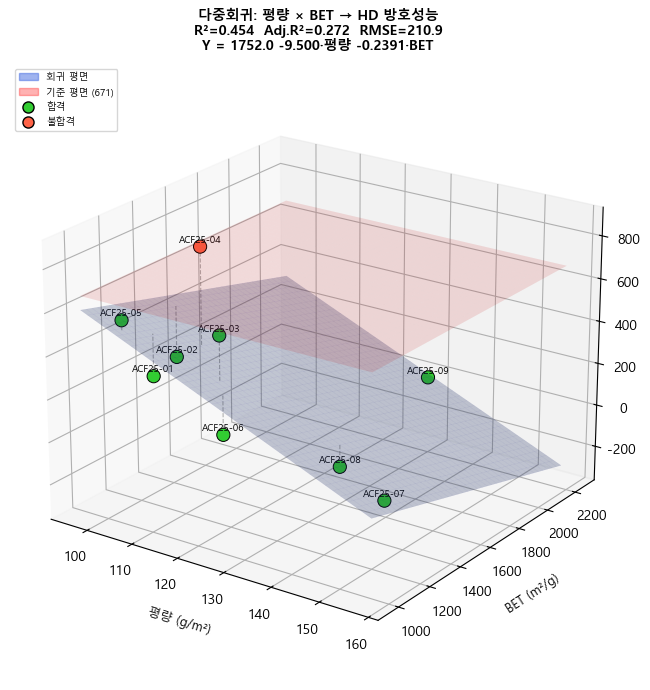

In [17]:
# ── Case 2: HD ──
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
plot_regression_3d(ax, df, 'HD_Con', HD_LIMIT,
                   '다중회귀: 평량 × BET → HD 방호성능', elev=22, azim=-55)
plt.tight_layout()
plt.show()

#### 📌 9-2 시각화 독해 가이드 (HD)

GD와 동일한 구조이며, 기준면이 HD = 671로 바뀝니다.

- HD는 기준값(671)이 GD(357)보다 높아, 더 많은 샘플이 기준면 아래(합격)에 위치할 것으로 예상됩니다.
- GD와 HD의 **회귀 평면 기울기 방향이 유사한지 다른지** 비교해보세요.  
  → 방향이 같다면 평량·BET가 GD·HD에 동일한 방식으로 영향을 미침을 의미합니다.  
  → 방향이 다르다면 두 작용제에 대한 소재의 거동 메커니즘이 다를 수 있습니다.

### 9-3. 평량 × BET → GD + HD (두 회귀 평면 동시 시각화)

  [GD]  Y = 1549.9 -6.277·평량 -0.2891·BET  | R²=0.182  Adj.R²=-0.091  RMSE=329.1
  [HD]  Y = 1752.0 -9.500·평량 -0.2391·BET  | R²=0.454  Adj.R²=0.272  RMSE=210.9


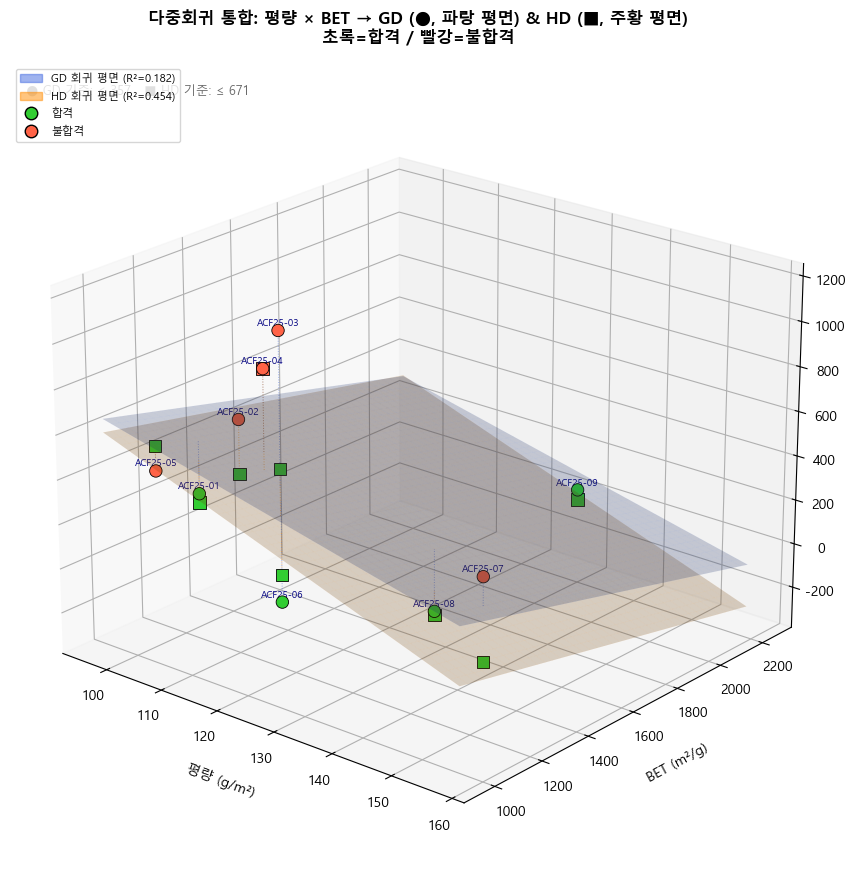

In [18]:
# ── Case 3: GD + HD 동시 ──
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

x1 = df['평량(g/m2)'].values
x2 = df['BET(m2/g)'].values

x1_grid = np.linspace(x1.min() - 3,  x1.max() + 3,  40)
x2_grid = np.linspace(x2.min() - 50, x2.max() + 50, 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)

for y_col, lim, surf_color, dot_color, label in [
    ('GD_Con', GD_LIMIT, 'royalblue',  'dodgerblue',   'GD'),
    ('HD_Con', HD_LIMIT, 'darkorange', 'gold',          'HD'),
]:
    m   = results[y_col]['model']
    b0, b1, b2 = m.params
    r2  = results[y_col]['r2']

    # 회귀 평면
    Zg = b0 + b1 * X1g + b2 * X2g
    ax.plot_surface(X1g, X2g, Zg, alpha=0.22, color=surf_color, edgecolor='none',
                    label=f'{label} 회귀 평면 (R²={r2:.3f})')
    ax.plot_wireframe(X1g, X2g, Zg, alpha=0.06, color=surf_color, linewidth=0.3)

    y_vals  = df[y_col].values
    y_pred  = results[y_col]['y_pred']

    # 잔차선
    for xi1, xi2, yi, yp in zip(x1, x2, y_vals, y_pred):
        ax.plot([xi1, xi1], [xi2, xi2], [yi, yp],
                color=surf_color, linewidth=0.7, linestyle=':', alpha=0.5)

    # 실제 점
    pt_colors = ['limegreen' if v <= lim else 'tomato' for v in y_vals]
    ax.scatter(x1, x2, y_vals, c=pt_colors, s=80, marker='o' if label=='GD' else 's',
               edgecolors='black', linewidths=0.6, depthshade=False, zorder=10)

    # 샘플 레이블 (GD만 표시, HD는 생략해 겹침 방지)
    if label == 'GD':
        for _, row in df.iterrows():
            ax.text(row['평량(g/m2)'], row['BET(m2/g)'], row[y_col] + 20,
                    row['Sample'], fontsize=7, ha='center', color='navy')

    # 회귀식 텍스트
    sign1 = '+' if b1 >= 0 else ''
    sign2 = '+' if b2 >= 0 else ''
    print(f"  [{label}]  Y = {b0:.1f} {sign1}{b1:.3f}·평량 {sign2}{b2:.4f}·BET  "
          f"| R²={r2:.3f}  Adj.R²={results[y_col]['adj_r2']:.3f}  RMSE={results[y_col]['rmse']:.1f}")

# 미군 기준 표시 (텍스트)
ax.text2D(0.02, 0.96, f'● GD 기준: ≤ {GD_LIMIT}   ■ HD 기준: ≤ {HD_LIMIT}',
          transform=ax.transAxes, fontsize=9, color='dimgray')

ax.set_xlabel('평량 (g/m²)', fontsize=10, labelpad=10)
ax.set_ylabel('BET (m²/g)',  fontsize=10, labelpad=10)
ax.set_zlabel('방호성능 Con (mg·min/m³)', fontsize=10, labelpad=10)
ax.set_title(
    '다중회귀 통합: 평량 × BET → GD (●, 파랑 평면) & HD (■, 주황 평면)\n'
    '초록=합격 / 빨강=불합격',
    fontsize=12, fontweight='bold', pad=14
)
ax.view_init(elev=22, azim=-50)

# 범례
from matplotlib.lines import Line2D
leg = [
    mpatches.Patch(color='royalblue',  alpha=0.5, label=f'GD 회귀 평면 (R²={results["GD_Con"]["r2"]:.3f})'),
    mpatches.Patch(color='darkorange', alpha=0.5, label=f'HD 회귀 평면 (R²={results["HD_Con"]["r2"]:.3f})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='limegreen',
           markersize=9, label='합격', markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
           markersize=9, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

#### 📌 9-3 시각화 독해 가이드 (GD + HD 통합)

| 요소 | 의미 |
|------|------|
| **파란 평면** | GD 회귀 평면 (● 원형 점이 실제 GD값) |
| **주황 평면** | HD 회귀 평면 (■ 사각 점이 실제 HD값) |
| **초록 점** | 해당 Y 기준 합격 |
| **빨간 점** | 해당 Y 기준 불합격 |
| **점선** | 각 Y의 잔차 (색이 같은 평면과 연결) |

**이 차트에서 확인할 사항**:
1. **두 평면의 기울기 방향이 같은가?** — GD와 HD가 같은 메커니즘으로 영향받는지 판단
2. **두 평면이 교차하는가?** — 교차한다면, 어떤 (평량, BET) 조건에서는 GD가 더 높고, 다른 조건에서는 HD가 더 높음을 의미
3. **합격 조건을 동시에 만족하는 영역** — 두 평면 모두가 각자의 기준면 아래로 내려가는 (평량, BET) 구간이 **설계 목표 구간**

> **설계 시사점**: 두 기준을 동시에 충족하는 최적 평량·BET 범위를 회귀 평면의 교차 형태를 통해 시각적으로 파악할 수 있습니다.

---
### 9-4. 회귀분석 종합 해석 및 한계

#### 결과 요약 (실행 후 수치로 확인)

| 모델 | 예상 방향 | 확인 포인트 |
|------|-----------|-------------|
| GD ~ 평량 + BET | BET↑→GD↓ (음), 평량은 방향 미정 | β₂ 부호와 유의성 |
| HD ~ 평량 + BET | BET↑→HD↓ (음), 평량은 방향 미정 | β₂ 부호와 유의성 |

#### 분석 한계 및 주의사항

1. **소표본 (n=9)**: 독립변수 2개에 대해 자유도가 6밖에 되지 않아 통계 검정력이 매우 낮습니다. 유의하지 않은 결과가 나오더라도 실질적 경향이 없다고 단정할 수 없습니다.

2. **선형 가정**: 현실의 흡착·투과 메커니즘은 비선형일 수 있습니다. 잔차가 크게 나타난다면 다항 회귀나 로그 변환을 추가 검토할 수 있습니다.

3. **다중공선성 주의**: 평량과 BET가 서로 상관된다면(EDA 섹션 5 참조), 각 계수의 해석이 불안정해질 수 있습니다.

4. **외삽 주의**: 회귀 모델은 관측된 데이터 범위 안에서만 신뢰할 수 있습니다. 평량·BET가 현재 범위를 크게 벗어난 신소재에 적용 시 예측 오차가 커질 수 있습니다.

#### 후속 분석 제안
- 데이터가 추가되면 **교차검증(CV)** 으로 예측 성능 검증
- 비선형 패턴 확인 시 **다항 회귀** 또는 **가우시안 프로세스 회귀** 적용 검토
- 잔차 정규성 검정 (Shapiro-Wilk), 등분산성 확인 추가

---
## 10. 베타 계수 유의성 심층 분석

다중 회귀에서 각 계수(β)가 통계적으로 의미 있는지, 두 예측변수 중 어느 쪽이 더 중요한지, 그리고 다중공선성 문제는 없는지 확인합니다.

| 분석 | 확인 내용 | 판단 기준 |
|------|-----------|-----------|
| **t-검정 / p-value** | 각 β가 0과 다른가 | p < 0.05 → 유의 |
| **95% 신뢰구간** | β 추정의 불확실성 범위 | 0을 포함하면 유의하지 않을 가능성 |
| **표준화 계수 β\*** | 단위를 제거한 상대적 영향력 | 절댓값이 클수록 Y에 미치는 영향 큼 |
| **VIF** | 예측변수 간 다중공선성 | > 10: 심각, > 5: 주의, ≤ 5: 양호 |

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vars = ['평량(g/m2)', 'BET(m2/g)']
X_raw  = df[X_vars].values
X_sm   = sm.add_constant(X_raw)

# ── VIF 계산 ──
vif_vals = [variance_inflation_factor(X_sm, i) for i in range(1, X_sm.shape[1])]

# ── X 표준화 (표준화 계수 계산용) ──
X_std = (df[X_vars] - df[X_vars].mean()) / df[X_vars].std()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_i, (y_col, label, lim) in enumerate([('GD_Con','GD',GD_LIMIT), ('HD_Con','HD',HD_LIMIT)]):
    m   = results[y_col]['model']
    y   = df[y_col].values

    # 표준화 계수
    y_std    = (y - y.mean()) / y.std()
    m_std    = sm.OLS(y_std, sm.add_constant(X_std.values)).fit()
    beta_std = np.asarray(m_std.params).flatten()[1:]   # 절편 제외

    # 신뢰구간 — numpy array로 안전하게 변환
    ci     = np.asarray(m.conf_int())          # shape (k, 2)
    params = np.asarray(m.params).flatten()
    pvals  = np.asarray(m.pvalues).flatten()
    ci_lo  = ci[1:, 0]                         # 절편 제외
    ci_hi  = ci[1:, 1]
    coefs  = params[1:]
    pv     = pvals[1:]

    # ── 왼쪽: 계수 Forest Plot (비표준화) ──
    ax_l = axes[row_i, 0]
    var_names  = ['평량(β₁)', 'BET(β₂)']
    colors_c   = ['tomato' if p >= 0.05 else 'steelblue' for p in pv]
    y_pos      = np.arange(len(var_names))

    for j, (c, lo, hi, col, p) in enumerate(zip(coefs, ci_lo, ci_hi, colors_c, pv)):
        ax_l.errorbar(c, j, xerr=[[c - lo], [hi - c]],
                      fmt='o', color=col, markersize=9, capsize=6, linewidth=2)
        sig_str = f'p={p:.3f}' + (' ★' if p < 0.05 else '')
        ax_l.text(hi + abs(hi - lo) * 0.05, j, sig_str,
                  va='center', fontsize=9, color=col)

    ax_l.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax_l.set_yticks(y_pos)
    ax_l.set_yticklabels(var_names, fontsize=11)
    ax_l.set_xlabel('계수 값 (95% CI)', fontsize=10)
    ax_l.set_title(f'[{label}] 비표준화 계수 + 95% CI\n(파랑=유의 p<0.05, 빨강=비유의)',
                   fontsize=11, fontweight='bold')

    # ── 오른쪽: 표준화 계수 비교 ──
    ax_r = axes[row_i, 1]
    bar_colors = ['steelblue', 'steelblue']
    bars = ax_r.barh(var_names, beta_std, color=bar_colors, edgecolor='black', height=0.4)
    ax_r.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    for bar, val in zip(bars, beta_std):
        offset = 0.02 if val >= 0 else -0.02
        ax_r.text(val + offset, bar.get_y() + bar.get_height() / 2,
                  f'{val:.3f}', va='center',
                  ha='left' if val >= 0 else 'right', fontsize=10)
    ax_r.set_xlabel('표준화 계수 β*', fontsize=10)
    ax_r.set_title(f'[{label}] 표준화 계수 (단위 제거, 상대적 중요도)',
                   fontsize=11, fontweight='bold')

plt.suptitle('베타 계수 유의성: 비표준화(95% CI) vs 표준화 계수', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 수치 요약 ──
print(f"\n{'='*62}")
print(f"  VIF (분산팽창계수) — 다중공선성 진단")
print(f"{'='*62}")
for var, v in zip(X_vars, vif_vals):
    status = '✅ 양호' if v < 5 else ('⚠️ 주의' if v < 10 else '❌ 심각')
    print(f"  {var:12s}: VIF = {v:.3f}  {status}")
print(f"\n  해석: VIF = 1/(1-R²_j), 변수 간 상관이 높을수록 커짐")
print(f"        VIF가 크면 계수 추정의 분산이 커져 신뢰구간이 넓어짐\n")

print(f"{'='*62}")
print(f"  계수 유의성 상세 테이블")
print(f"{'='*62}")
for y_col, label in [('GD_Con','GD'), ('HD_Con','HD')]:
    m      = results[y_col]['model']
    ci     = np.asarray(m.conf_int())
    params = np.asarray(m.params).flatten()
    pvals  = np.asarray(m.pvalues).flatten()
    bse    = np.asarray(m.bse).flatten()
    tvals  = np.asarray(m.tvalues).flatten()
    print(f"\n  [{label}]")
    print(f"  {'변수':12s} {'계수':>10s} {'표준오차':>10s} {'t값':>8s} {'p값':>8s} {'CI 하한':>10s} {'CI 상한':>10s}")
    print(f"  {'-'*74}")
    names = ['절편(β₀)', '평량(β₁)', 'BET(β₂)']
    for i, nm in enumerate(names):
        sig = ' ★' if (i > 0 and pvals[i] < 0.05) else ''
        print(f"  {nm:12s} {params[i]:>10.4f} {bse[i]:>10.4f} "
              f"{tvals[i]:>8.3f} {pvals[i]:>8.4f} "
              f"{ci[i,0]:>10.4f} {ci[i,1]:>10.4f}{sig}")

---
## 11. 비선형성 진단 및 스플라인 회귀

### 분석 흐름

```
잔차 진단 플롯 → RESET 검정 → 비선형 의심 시 → 스플라인 적합 → 선형 vs 스플라인 비교 → 3D 시각화
```

| 단계 | 도구 | 판단 기준 |
|------|------|-----------|
| **잔차 vs 적합값** | 산점도 | 패턴(곡선, 부채꼴) 있으면 비선형·이분산 의심 |
| **Q-Q Plot** | 정규분위수도 | 대각선 이탈 → 잔차 비정규 |
| **Scale-Location** | √|표준화잔차| vs 적합값 | 우상향 패턴 → 이분산 |
| **Leverage (Cook's D)** | 영향력 점 | Cook's D > 4/n → 영향력 강한 관측치 |
| **RESET 검정** | Ramsey RESET | p < 0.05 → 유의한 비선형성 존재 |

**스플라인 회귀**: 데이터를 여러 구간으로 나눠 각 구간에서 다항식을 부드럽게 연결합니다.  
n=9 소규모이므로 내부 매듭(knot) 1개짜리 **자연 3차 스플라인(Natural Cubic Spline)** 을 사용합니다.

In [ ]:
from statsmodels.stats.diagnostic import linear_reset
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

def residual_diagnostics(ax_list, model, label):
    fitted    = np.asarray(model.fittedvalues).flatten()
    residuals = np.asarray(model.resid).flatten()
    std_resid = np.asarray(model.get_influence().resid_studentized_internal).flatten()
    cooks_d   = np.asarray(model.get_influence().cooks_distance[0]).flatten()
    n         = len(residuals)
    samples   = df['Sample'].tolist()

    # 1. Residuals vs Fitted
    ax = ax_list[0]
    ax.scatter(fitted, residuals, color='steelblue', edgecolors='black', s=60)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    lw = lowess(residuals, fitted, frac=0.8)
    ax.plot(lw[:, 0], lw[:, 1], color='darkorange', linewidth=2, label='LOWESS')
    for idx, (xi, yi) in enumerate(zip(fitted, residuals)):
        ax.annotate(samples[idx], (xi, yi),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('적합값 (Fitted)', fontsize=9)
    ax.set_ylabel('잔차 (Residual)', fontsize=9)
    ax.set_title(f'[{label}] Residuals vs Fitted\n패턴 없어야 선형성 만족', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

    # 2. Q-Q Plot — 기본 호출 후 스타일 후처리
    ax = ax_list[1]
    pp = ProbPlot(residuals)
    pp.qqplot(line='s', ax=ax, alpha=0.8)
    # 점 스타일 후처리
    for line in ax.get_lines():
        if line.get_linestyle() == 'None':   # 데이터 점
            line.set_color('steelblue')
            line.set_markersize(7)
            line.set_markeredgecolor('black')
    ax.set_title(f'[{label}] Normal Q-Q Plot\n대각선 근접 → 정규성 만족', fontsize=10, fontweight='bold')

    # 3. Scale-Location
    ax = ax_list[2]
    sqrt_std = np.sqrt(np.abs(std_resid))
    ax.scatter(fitted, sqrt_std, color='seagreen', edgecolors='black', s=60)
    lw2 = lowess(sqrt_std, fitted, frac=0.8)
    ax.plot(lw2[:, 0], lw2[:, 1], color='darkorange', linewidth=2)
    ax.set_xlabel('적합값 (Fitted)', fontsize=9)
    ax.set_ylabel('√|표준화잔차|', fontsize=9)
    ax.set_title(f'[{label}] Scale-Location\n수평이어야 등분산 만족', fontsize=10, fontweight='bold')

    # 4. Cook's Distance
    ax = ax_list[3]
    threshold = 4 / n
    bar_colors = ['tomato' if c > threshold else 'steelblue' for c in cooks_d]
    ax.bar(samples, cooks_d, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
               label=f'기준 4/n = {threshold:.3f}')
    ax.set_xlabel('Sample', fontsize=9)
    ax.set_ylabel("Cook's Distance", fontsize=9)
    ax.set_title(f"[{label}] Cook's Distance\n빨강 막대 → 영향력 강한 관측치", fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

# ── 4×4 진단 플롯 (GD / HD) ──
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for row_i, (y_col, label) in enumerate([('GD_Con', 'GD'), ('HD_Con', 'HD')]):
    residual_diagnostics(axes[row_i], results[y_col]['model'], label)

plt.suptitle('잔차 진단 4종 플롯', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── RESET 검정 ──
print(f"\n{'='*52}")
print(f"  Ramsey RESET 검정 (비선형성 공식 검정)")
print(f"  귀무가설 H₀: 선형 모델이 적절하다")
print(f"{'='*52}")
for y_col, label in [('GD_Con', 'GD'), ('HD_Con', 'HD')]:
    reset = linear_reset(results[y_col]['model'], power=2, use_f=True)
    verdict = '❌ 비선형성 의심 (스플라인 권장)' if reset.pvalue < 0.05 else '✅ 선형 모델 적절'
    print(f"  [{label}]  F={reset.statistic:.4f},  p={reset.pvalue:.4f}  →  {verdict}")

### 11-2. 스플라인 회귀 적합 및 선형 모델 비교

각 X변수에 대해 **자연 3차 스플라인(Natural Cubic Spline, NCS)** 을 독립적으로 적합하고, 선형 모델과 비교합니다.  
n=9에서 과적합을 막기 위해 내부 매듭(knot)을 **중앙값(1개)** 에만 설정합니다.

In [ ]:
import patsy

def natural_spline_basis(x, knots):
    """자연 3차 스플라인 기저 행렬 생성 (patsy cr() 사용)"""
    x_series = pd.Series(x, name='x')
    formula  = f"cr(x, knots={knots}, lower_bound={x.min()}, upper_bound={x.max()})"
    return patsy.dmatrix(formula, {'x': x_series}, return_type='dataframe')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
spline_results = {}

for col_i, (x_col, x_label) in enumerate([('평량(g/m2)','평량 (g/m²)'), ('BET(m2/g)','BET (m²/g)')]):
    x_vals = df[x_col].values
    knot   = float(np.median(x_vals))   # 중앙값 1개를 매듭으로
    x_fine = np.linspace(x_vals.min(), x_vals.max(), 200)

    for row_i, (y_col, y_label, lim) in enumerate([('GD_Con','GD',GD_LIMIT), ('HD_Con','HD',HD_LIMIT)]):
        ax  = axes[row_i, col_i]
        y   = df[y_col].values

        # ── 선형 단순회귀 ──
        m_lin   = sm.OLS(y, sm.add_constant(x_vals)).fit()
        y_lin   = m_lin.params[0] + m_lin.params[1] * x_fine
        r2_lin  = m_lin.rsquared

        # ── 스플라인 회귀 ──
        B_train = natural_spline_basis(x_vals, [knot])
        B_pred  = natural_spline_basis(x_fine,  [knot])
        m_spl   = sm.OLS(y, B_train).fit()
        y_spl   = m_spl.predict(B_pred)
        r2_spl  = m_spl.rsquared
        aic_lin = m_lin.aic
        aic_spl = m_spl.aic

        spline_results[(x_col, y_col)] = dict(r2_lin=r2_lin, r2_spl=r2_spl,
                                               aic_lin=aic_lin, aic_spl=aic_spl)

        # ── 실제 데이터 점 ──
        pt_colors = ['limegreen' if v <= lim else 'tomato' for v in y]
        ax.scatter(x_vals, y, c=pt_colors, s=80, edgecolors='black',
                   linewidths=0.7, zorder=5, label='실제값')
        for xi, yi, smp in zip(x_vals, y, df['Sample']):
            ax.annotate(smp, (xi, yi), fontsize=7,
                        xytext=(3, 5), textcoords='offset points')

        # ── 선형 회귀선 ──
        ax.plot(x_fine, y_lin, color='royalblue', linewidth=2,
                linestyle='--', label=f'선형 (R²={r2_lin:.3f})')

        # ── 스플라인 곡선 ──
        ax.plot(x_fine, y_spl, color='darkorange', linewidth=2.5,
                label=f'스플라인 NCS (R²={r2_spl:.3f})')

        # 매듭 표시
        ax.axvline(knot, color='gray', linestyle=':', linewidth=1.2,
                   label=f'매듭 = {knot:.1f}')

        # 기준선
        ax.axhline(lim, color='red', linestyle='--', linewidth=1,
                   alpha=0.6, label=f'미군 기준 {lim}')

        # AIC 비교 텍스트
        better = '스플라인' if aic_spl < aic_lin else '선형'
        ax.text(0.02, 0.98,
                f'AIC 선형={aic_lin:.1f}\nAIC 스플라인={aic_spl:.1f}\n→ {better} 우세',
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(f'{y_label} Con (mg·min/m³)', fontsize=9)
        ax.set_title(f'{x_label} → {y_label}\n(단변량 스플라인)', fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('선형 회귀 vs 자연 3차 스플라인(NCS) — 단변량 비교\n(초록=합격, 빨강=불합격)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 비교 요약
print(f"\n{'='*60}")
print(f"  선형 vs 스플라인 비교 (단변량, 내부 매듭=중앙값 1개)")
print(f"{'='*60}")
print(f"  {'조합':22s} {'R²_선형':>8s} {'R²_스플라인':>12s} {'ΔAIC':>8s} {'우세모델':>10s}")
print(f"  {'-'*66}")
for (xc, yc), v in spline_results.items():
    delta = v['aic_spl'] - v['aic_lin']
    better = '스플라인' if delta < -2 else ('선형' if delta > 2 else '유사')
    print(f"  {xc+' → '+yc:22s} {v['r2_lin']:>8.3f} {v['r2_spl']:>12.3f} {delta:>8.2f} {better:>10s}")
print(f"\n  ※ ΔAIC < -2: 스플라인이 유의미하게 우세 / > +2: 선형이 우세")

### 11-3. 스플라인 회귀면 3D 시각화 (평량 + BET 동시 적합)

In [ ]:
from patsy import dmatrix as pdmatrix

def fit_additive_spline(df, y_col):
    """GAM 스타일 가산 모델: Y ~ NCS(평량) + NCS(BET), 매듭=각 중앙값"""
    x1 = df['평량(g/m2)'].values
    x2 = df['BET(m2/g)'].values
    y  = df[y_col].values
    k1, k2 = float(np.median(x1)), float(np.median(x2))

    formula = (f"cr(평량, knots=[{k1}], lower_bound={x1.min()}, upper_bound={x1.max()})"
               f" + cr(BET, knots=[{k2}], lower_bound={x2.min()}, upper_bound={x2.max()})")
    data_dict = {'평량': x1, 'BET': x2}
    B_train = pdmatrix(formula, data_dict, return_type='dataframe')
    model   = sm.OLS(y, B_train).fit()
    return model, formula, data_dict, k1, k2

fig = plt.figure(figsize=(16, 7))

for idx, (y_col, label, lim, surf_color) in enumerate([
    ('GD_Con', 'GD', GD_LIMIT, 'royalblue'),
    ('HD_Con', 'HD', HD_LIMIT, 'darkorange'),
]):
    ax = fig.add_subplot(1, 2, idx+1, projection='3d')

    x1v = df['평량(g/m2)'].values
    x2v = df['BET(m2/g)'].values
    y   = df[y_col].values

    m_spl, formula, ddict, k1, k2 = fit_additive_spline(df, y_col)
    m_lin = results[y_col]['model']

    # 예측 그리드
    x1g = np.linspace(x1v.min()-2, x1v.max()+2, 30)
    x2g = np.linspace(x2v.min()-50, x2v.max()+50, 30)
    X1g, X2g = np.meshgrid(x1g, x2g)

    grid_dict = {'평량': X1g.ravel(), 'BET': X2g.ravel()}
    B_grid    = pdmatrix(formula, grid_dict, return_type='dataframe')
    Zg_spl    = m_spl.predict(B_grid).values.reshape(X1g.shape)

    # 선형 예측면
    b = m_lin.params
    Zg_lin = b[0] + b[1]*X1g + b[2]*X2g

    # 스플라인 면
    ax.plot_surface(X1g, X2g, Zg_spl, alpha=0.30, color=surf_color, edgecolor='none')
    ax.plot_wireframe(X1g, X2g, Zg_spl, alpha=0.06, color=surf_color, linewidth=0.3)

    # 선형 면 (반투명 회색)
    ax.plot_surface(X1g, X2g, Zg_lin, alpha=0.10, color='gray', edgecolor='none')

    # 기준 평면
    Zlim = np.full_like(X1g, lim)
    ax.plot_surface(X1g, X2g, Zlim, alpha=0.10, color='red', edgecolor='none')

    # 잔차선 + 실제 점
    y_spl_pred = m_spl.fittedvalues
    for xi1, xi2, yi, yp in zip(x1v, x2v, y, y_spl_pred):
        ax.plot([xi1,xi1],[xi2,xi2],[yi,yp],
                color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    pt_colors = ['limegreen' if v<=lim else 'tomato' for v in y]
    ax.scatter(x1v, x2v, y, c=pt_colors, s=90,
               edgecolors='black', linewidths=0.6, depthshade=False, zorder=10)
    for _, row in df.iterrows():
        ax.text(row['평량(g/m2)'], row['BET(m2/g)'], row[y_col]+20,
                row['Sample'], fontsize=7, ha='center')

    r2_s = m_spl.rsquared
    r2_l = m_lin.rsquared
    ax.set_xlabel('평량 (g/m²)', fontsize=9, labelpad=8)
    ax.set_ylabel('BET (m²/g)',  fontsize=9, labelpad=8)
    ax.set_zlabel(f'{label} Con', fontsize=9, labelpad=8)
    ax.set_title(
        f'스플라인 회귀면: 평량 × BET → {label}\n'
        f'스플라인 R²={r2_s:.3f}  vs  선형 R²={r2_l:.3f}\n'
        f'(색 평면=스플라인, 회색=선형, 빨강=기준)',
        fontsize=10, fontweight='bold', pad=12
    )
    ax.view_init(elev=22, azim=-50)

    # 범례
    leg = [
        mpatches.Patch(color=surf_color, alpha=0.5, label='스플라인 회귀면'),
        mpatches.Patch(color='gray',     alpha=0.3, label='선형 회귀면'),
        mpatches.Patch(color='red',      alpha=0.2, label=f'기준면 ({lim})'),
    ]
    ax.legend(handles=leg, fontsize=7, loc='upper left')

plt.suptitle('가산 스플라인 회귀면 vs 선형 회귀면 3D 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. 공분산 행렬 추정 진단

회귀계수 추정량 β̂의 공분산 행렬 **Var(β̂) = σ²(X'X)⁻¹** 이 얼마나 신뢰할 수 있는지 확인합니다.  
이 행렬이 잘못 추정되면 표준오차, 신뢰구간, p-value 모두 왜곡됩니다.

| 진단 | 의미 | 기준 |
|------|------|------|
| **조건수 (Condition Number)** | X'X 행렬의 수치적 안정성. 클수록 다중공선성으로 추정 불안정 | < 30: 양호 / 30~100: 주의 / > 100: 위험 |
| **Breusch-Pagan 검정** | 잔차 분산이 X에 따라 달라지는지 (이분산성) | p < 0.05 → 이분산, OLS 표준오차 과소 또는 과대 추정 |
| **Shapiro-Wilk 검정** | 잔차 정규성. 비정규 시 소표본에서 p-value 신뢰도 저하 | p < 0.05 → 비정규 의심 |
| **강건 표준오차 (HC3)** | 이분산에 강건한 표준오차. OLS SE와 크게 다르면 이분산 문제 존재 | OLS SE와 비교 |

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

X_sm = sm.add_constant(df[X_vars].values)

# ── 조건수 & 고유값 ──
XtX    = X_sm.T @ X_sm
eigvals= np.linalg.eigvalsh(XtX)
cond_n = results['GD_Con']['model'].condition_number  # statsmodels 내장

print(f"{'='*60}")
print(f"  X'X 행렬 고유값 및 조건수 (X = [1, 평량, BET])")
print(f"{'='*60}")
print(f"  고유값: {np.sort(eigvals)[::-1]}")
print(f"  조건수 (Condition Number): {cond_n:.2f}")
if cond_n < 30:
    print(f"  → ✅ 양호: 공분산 추정 수치적으로 안정")
elif cond_n < 100:
    print(f"  → ⚠️  주의: 다중공선성으로 추정 다소 불안정할 수 있음")
else:
    print(f"  → ❌ 위험: 강한 다중공선성, 계수 추정 신뢰도 낮음")

# ── 공분산 행렬 출력 ──
print(f"\n{'='*60}")
print(f"  Var(β̂) = σ²·(X'X)⁻¹  [GD 기준]")
print(f"{'='*60}")
cov_mat = results['GD_Con']['model'].cov_params()
cov_df  = pd.DataFrame(cov_mat.values,
                        index  =['절편', '평량', 'BET'],
                        columns=['절편', '평량', 'BET'])
print(cov_df.round(4).to_string())
print("\n  대각 원소 = 각 β̂의 분산, 제곱근 = 표준오차(SE)")
print("  비대각 원소 = 계수 간 공분산 (음수 = 역상관 관계)")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 공분산 행렬 히트맵 (GD) ──
ax = axes[0]
cov_corr = cov_df / (np.sqrt(np.diag(cov_df.values))[:, None] *
                     np.sqrt(np.diag(cov_df.values))[None, :])
sns.heatmap(cov_corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink':0.8})
ax.set_title('공분산 → 상관행렬\n(Var(β̂) 기반, GD)', fontsize=11, fontweight='bold')

# ── OLS SE vs HC3 Robust SE ──
ax = axes[1]
var_names = ['절편(β₀)', '평량(β₁)', 'BET(β₂)']
x_pos = np.arange(len(var_names))
width = 0.35

for yi, (y_col, label, color) in enumerate([('GD_Con','GD','steelblue'),
                                             ('HD_Con','HD','darkorange')]):
    m_ols  = results[y_col]['model']
    m_hc3  = m_ols.get_robustcov_results(cov_type='HC3')
    se_ols = m_ols.bse
    se_hc3 = m_hc3.bse

    offset = (yi - 0.5) * width
    ax.bar(x_pos + offset - width/2, se_ols, width=width/2,
           label=f'{label} OLS SE', color=color, alpha=0.7, edgecolor='black')
    ax.bar(x_pos + offset,           se_hc3, width=width/2,
           label=f'{label} HC3 SE', color=color, alpha=0.4, edgecolor='black',
           hatch='//')

ax.set_xticks(x_pos)
ax.set_xticklabels(var_names, fontsize=9)
ax.set_ylabel('표준오차 (SE)', fontsize=10)
ax.set_title('OLS SE vs HC3 강건 SE\n(차이 클수록 이분산 문제)', fontsize=11, fontweight='bold')
ax.legend(fontsize=7, ncol=2)

# ── Breusch-Pagan + Shapiro-Wilk 결과 막대 ──
ax = axes[2]
tests = []
for y_col, label in [('GD_Con','GD'), ('HD_Con','HD')]:
    m    = results[y_col]['model']
    resid= m.resid.values
    # Breusch-Pagan
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, X_sm)
    # Shapiro-Wilk
    sw_stat, sw_p = shapiro(resid)
    tests.append({'label': label, 'BP_p': bp_p, 'SW_p': sw_p})

test_labels = ['GD\nBreusch-Pagan', 'GD\nShapiro-Wilk', 'HD\nBreusch-Pagan', 'HD\nShapiro-Wilk']
p_vals = [tests[0]['BP_p'], tests[0]['SW_p'], tests[1]['BP_p'], tests[1]['SW_p']]
bar_c  = ['tomato' if p < 0.05 else 'steelblue' for p in p_vals]

bars = ax.bar(test_labels, p_vals, color=bar_c, edgecolor='black', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', linewidth=2, label='유의수준 α=0.05')
for bar, p in zip(bars, p_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{p:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('p-value', fontsize=10)
ax.set_ylim(0, max(p_vals)*1.3 + 0.1)
ax.set_title('등분산성·정규성 검정 p-value\n(빨강=0.05 미만, 가정 위반 의심)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('공분산 행렬 추정 진단', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 수치 요약 ──
print(f"\n{'='*60}")
print(f"  검정 결과 요약")
print(f"{'='*60}")
for t in tests:
    lbl = t['label']
    bp_v = '❌ 이분산 의심' if t['BP_p'] < 0.05 else '✅ 등분산 가정 유지'
    sw_v = '❌ 비정규 의심'  if t['SW_p'] < 0.05 else '✅ 정규성 가정 유지'
    print(f"  [{lbl}]")
    print(f"    Breusch-Pagan  p={t['BP_p']:.4f}  →  {bp_v}")
    print(f"    Shapiro-Wilk   p={t['SW_p']:.4f}  →  {sw_v}")
    m_ols = results[lbl+'_Con']['model']
    m_hc3 = m_ols.get_robustcov_results(cov_type='HC3')
    se_ratio = m_hc3.bse[1:] / m_ols.bse[1:]
    print(f"    HC3/OLS SE 비 (평량, BET): {se_ratio.values[0]:.3f}, {se_ratio.values[1]:.3f}")
    if any(abs(se_ratio - 1) > 0.3):
        print(f"    → ⚠️  SE 비율이 크게 다름: 이분산 하에서 OLS 추론 신뢰도 낮을 수 있음")
    else:
        print(f"    → ✅ SE 비율 유사: OLS 표준오차 신뢰 가능")
    print()

## 8. EDA 종합 요약

In [19]:
print("=" * 55)
print("         EDA 종합 요약")
print("=" * 55)

print("\n[1] 데이터 현황]")
print(f"  - 총 샘플: {len(df)}개, 결측치 없음")
print(f"  - 평량 범위: {df['평량(g/m2)'].min():.1f} ~ {df['평량(g/m2)'].max():.1f} g/m²  (CV: {df['평량(g/m2)'].std()/df['평량(g/m2)'].mean()*100:.1f}%)")
print(f"  - BET 범위:  {df['BET(m2/g)'].min()} ~ {df['BET(m2/g)'].max()} m²/g  (CV: {df['BET(m2/g)'].std()/df['BET(m2/g)'].mean()*100:.1f}%)")

print("\n[2] 미군 기준 Pass/Fail]")
print(f"  - GD (≤{GD_LIMIT}): 합격 {df['GD_pass'].sum()}개 / 불합격 {(~df['GD_pass']).sum()}개")
print(f"  - HD (≤{HD_LIMIT}): 합격 {df['HD_pass'].sum()}개 / 불합격 {(~df['HD_pass']).sum()}개")
print(f"  - GD+HD 동시 합격: {df['ALL_pass'].sum()}개")
passed = df[df['ALL_pass']]['Sample'].tolist()
print(f"    → 합격 샘플: {passed}")

print("\n[3] 상관관계 분석 결과]")
num_cols = ['평량(g/m2)', 'BET(m2/g)', 'GD_Con', 'HD_Con']
corr = df[num_cols].corr()
for x in ['평량(g/m2)', 'BET(m2/g)']:
    for y in ['GD_Con', 'HD_Con']:
        r = corr.loc[x, y]
        _, p = stats.pearsonr(df[x], df[y])
        direction = '음(-)' if r < 0 else '양(+)'
        strength = '강함' if abs(r) > 0.7 else ('중간' if abs(r) > 0.4 else '약함')
        sig = '유의★' if p < 0.05 else '비유의'
        print(f"  {x} → {y}: r={r:.3f} ({direction}, {strength}), p={p:.3f} [{sig}]")

print("\n[4] 해석 및 시사점]")
print("  - 소규모(n=9) 데이터로 통계적 유의성 해석 시 주의 필요")
print("  - BET(미세기공 면적)이 클수록 방호성능 향상 경향 확인 필요")
print("  - 평량(무게)과 방호성능 간 관계도 추가 분석 필요")
print("  - GD 기준 충족이 더 어려운 경향 (합격률 낮음)")
print("=" * 55)

         EDA 종합 요약

[1] 데이터 현황]
  - 총 샘플: 9개, 결측치 없음
  - 평량 범위: 99.3 ~ 154.5 g/m²  (CV: 15.3%)
  - BET 범위:  1016 ~ 2197 m²/g  (CV: 27.4%)

[2] 미군 기준 Pass/Fail]
  - GD (≤357): 합격 4개 / 불합격 5개
  - HD (≤671): 합격 8개 / 불합격 1개
  - GD+HD 동시 합격: 4개
    → 합격 샘플: ['ACF25-01', 'ACF25-06', 'ACF25-08', 'ACF25-09']

[3] 상관관계 분석 결과]
  평량(g/m2) → GD_Con: r=-0.333 (음(-), 약함), p=0.381 [비유의]
  평량(g/m2) → HD_Con: r=-0.613 (음(-), 중간), p=0.079 [비유의]
  BET(m2/g) → GD_Con: r=-0.306 (음(-), 약함), p=0.423 [비유의]
  BET(m2/g) → HD_Con: r=-0.355 (음(-), 약함), p=0.348 [비유의]

[4] 해석 및 시사점]
  - 소규모(n=9) 데이터로 통계적 유의성 해석 시 주의 필요
  - BET(미세기공 면적)이 클수록 방호성능 향상 경향 확인 필요
  - 평량(무게)과 방호성능 간 관계도 추가 분석 필요
  - GD 기준 충족이 더 어려운 경향 (합격률 낮음)
